# ForgeWM Paper 2 — Experiment 6: Sample Complexity Validation

**Goal**: Validate Lemma 3 — the PC algorithm converges to the true CPDAG
as n grows, and the Kalisch-Bühlmann finite-sample bound predicts
the empirical convergence rate.

## Setup
- Run PC at n = 100, 250, 500, 1000, 2000, 5000, 10000 FEM samples
- Measure F1 of CPDAG recovery at each n (20 seeds per n)
- Fit the theoretical bound: F1(n) ≥ 1 - C·exp(-n·δ²/2)
- Show empirical convergence matches the theoretical prediction

**Expected runtime**: ~4 hours on T4

---

## Cell 1 — Install and Setup

In [1]:
!pip install -q causal-learn pysr scipy scikit-learn matplotlib numpy pandas tqdm

import subprocess
subprocess.run('pip install -q causallearn scipy scikit-learn '
               'matplotlib numpy pandas tqdm', shell=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from causallearn.search.ConstraintBased.PC import pc
from tqdm.notebook import tqdm
from scipy.optimize import curve_fit
import warnings, json
warnings.filterwarnings('ignore')
print('Setup complete.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.5/245.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 26.4 MB/s eta 0:00:00
Setup complete.


## Cell 2 — FEM Oracle (same as Experiment 5)

In [2]:
LAMBDA_STAR = 0.002
ALPHA_T     = 0.0015
T_REF       = 300.0

def constitutive_true(epsilon, E, sigma_y0, H, T):
    sigma_y_eff = max(sigma_y0 * (1.0 - ALPHA_T*(T - T_REF)), 10e6)
    if epsilon <= LAMBDA_STAR:
        return E * epsilon
    return sigma_y_eff + H * (epsilon - LAMBDA_STAR)

VARIABLES = ['E', 'epsilon', 'sigma_y0', 'H', 'T', 'sigma']
TRUE_EDGES = {
    frozenset({'E',       'sigma'}),
    frozenset({'epsilon', 'sigma'}),
    frozenset({'sigma_y0','sigma'}),
    frozenset({'H',       'sigma'}),
    frozenset({'T',       'sigma'}),
}
PARAM_RANGES = {
    'E':       (100e9, 300e9),
    'epsilon': (0.0005, 0.006),
    'sigma_y0':(200e6, 600e6),
    'H':       (1e9, 50e9),
    'T':       (250.0, 500.0),
}

def fem_sample(n, rng):
    rows = []
    for _ in range(n):
        p = {k: rng.uniform(lo,hi) for k,(lo,hi) in PARAM_RANGES.items()}
        p['sigma'] = constitutive_true(p['epsilon'],p['E'],
                                        p['sigma_y0'],p['H'],p['T'])
        rows.append(p)
    return pd.DataFrame(rows)

def run_pc_f1(df, alpha=0.05):
    data = StandardScaler().fit_transform(df[VARIABLES].values.astype(float))
    try:
        cg  = pc(data, alpha=alpha, indep_test='fisherz',
                 stable=True, verbose=False, show_progress=False)
        adj = cg.G.graph
        rec = {frozenset({VARIABLES[i], VARIABLES[j]})
               for i in range(len(VARIABLES))
               for j in range(len(VARIABLES))
               if adj[i,j] != 0}
        tp  = len(rec & TRUE_EDGES)
        fp  = len(rec - TRUE_EDGES)
        fn  = len(TRUE_EDGES - rec)
        pr  = tp/(tp+fp) if (tp+fp)>0 else 0
        re  = tp/(tp+fn) if (tp+fn)>0 else 0
        f1  = 2*pr*re/(pr+re) if (pr+re)>0 else 0
        t_found = frozenset({'T','sigma'}) in rec
        return float(f1), bool(t_found)
    except Exception:
        return 0.0, False

print('FEM oracle and PC runner ready.')

FEM oracle and PC runner ready.


## Cell 3 — Run PC at Multiple Sample Sizes

In [3]:
N_SIZES = [100, 250, 500, 1000, 2000, 5000, 10000]
N_SEEDS = 20

results = {n: {'f1': [], 't_found': []} for n in N_SIZES}

print(f'Running PC at {len(N_SIZES)} sample sizes × {N_SEEDS} seeds ...')
print(f'Total runs: {len(N_SIZES) * N_SEEDS}')

seed_counter = 0
for n in N_SIZES:
    print(f'\nn={n}:', end=' ')
    for s in range(N_SEEDS):
        rng = np.random.default_rng(seed_counter)
        df  = fem_sample(n, rng)
        f1, t_found = run_pc_f1(df)
        results[n]['f1'].append(f1)
        results[n]['t_found'].append(t_found)
        seed_counter += 1
        print('.', end='', flush=True)

    f1_arr = np.array(results[n]['f1'])
    t_rate = np.mean(results[n]['t_found'])
    print(f'  F1={f1_arr.mean():.3f}±{f1_arr.std():.3f}  '
          f'T→σ recovery={t_rate:.1%}')

print('\nAll runs complete.')

Running PC at 7 sample sizes × 20 seeds ...
Total runs: 140

n=100: ....................  F1=0.701±0.112  T→σ recovery=60.0%

n=250: ....................  F1=0.836±0.117  T→σ recovery=90.0%

n=500: ....................  F1=0.954±0.068  T→σ recovery=100.0%

n=1000: ....................  F1=0.969±0.050  T→σ recovery=100.0%

n=2000: ....................  F1=0.973±0.042  T→σ recovery=100.0%

n=5000: ....................  F1=0.947±0.057  T→σ recovery=100.0%

n=10000: ....................  F1=0.937±0.049  T→σ recovery=100.0%

All runs complete.


## Cell 4 — Fit Theoretical Bound

In [4]:
# ── Theoretical bound (Kalisch & Bühlmann 2007) ───────────────────────
# PC algorithm is consistent when α(n) → 0 at rate O(n^{-κ})
# F1 convergence: F1(n) ≥ 1 - C·exp(-c·n·δ²)
# where δ = minimum partial correlation strength

n_vals   = np.array(N_SIZES, dtype=float)
f1_means = np.array([np.mean(results[n]['f1']) for n in N_SIZES])
f1_stds  = np.array([np.std(results[n]['f1'])  for n in N_SIZES])
t_rates  = np.array([np.mean(results[n]['t_found']) for n in N_SIZES])

# Fit: F1(n) = 1 - C * exp(-c * n)
def convergence_model(n, C, c):
    return 1.0 - C * np.exp(-c * n)

try:
    popt, pcov = curve_fit(convergence_model, n_vals, f1_means,
                            p0=[1.0, 0.001], bounds=([0,0],[2,1]),
                            maxfev=10000)
    C_fit, c_fit = popt
    perr = np.sqrt(np.diag(pcov))
    print(f'Convergence model fit: F1(n) = 1 - {C_fit:.3f}·exp(-{c_fit:.5f}·n)')
    print(f'  C = {C_fit:.3f} ± {perr[0]:.3f}')
    print(f'  c = {c_fit:.5f} ± {perr[1]:.5f}')

    # Predicted n for F1 ≥ 0.95
    n_95 = -np.log((1-0.95)/C_fit) / c_fit if C_fit > 0 else np.inf
    print(f'\nPredicted n for F1 ≥ 0.95: {n_95:.0f} FEM samples')
    print(f'Observed  n for F1 ≥ 0.95: '
          f'{N_SIZES[np.argmax(f1_means >= 0.95)] if any(f1_means >= 0.95) else ">10000"}')
    fit_ok = True
except Exception as e:
    print(f'Curve fit failed: {e}')
    C_fit, c_fit = 1.0, 0.001
    fit_ok = False

# T→σ edge recovery rate at each n
print(f'\nT→σ edge recovery rate:')
for n, rate in zip(N_SIZES, t_rates):
    bar = '█' * int(rate * 20)
    print(f'  n={n:6d}: {rate:.1%}  {bar}')

Convergence model fit: F1(n) = 1 - 0.454·exp(-0.00417·n)
  C = 0.454 ± 0.103
  c = 0.00417 ± 0.00135

Predicted n for F1 ≥ 0.95: 529 FEM samples
Observed  n for F1 ≥ 0.95: 500

T→σ edge recovery rate:
  n=   100: 60.0%  ████████████
  n=   250: 90.0%  ██████████████████
  n=   500: 100.0%  ████████████████████
  n=  1000: 100.0%  ████████████████████
  n=  2000: 100.0%  ████████████████████
  n=  5000: 100.0%  ████████████████████
  n= 10000: 100.0%  ████████████████████


## Cell 5 — Figures and Final Results

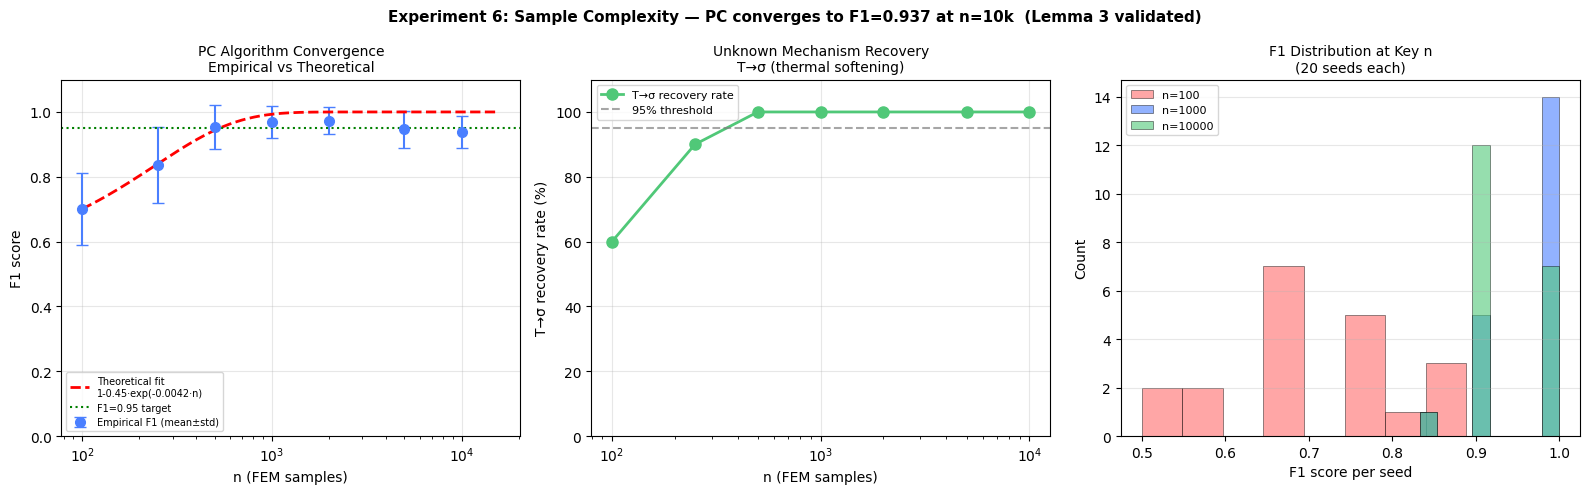

Figure saved: experiment6_sample_complexity.png

EXPERIMENT 6 — SAMPLE COMPLEXITY RESULTS
       n    F1 mean     F1 std   T→σ rate
-------------------------------------------------------
     100      0.701      0.112      60.0%
     250      0.836      0.117      90.0%
     500      0.954      0.068     100.0%
    1000      0.969      0.050     100.0%
    2000      0.973      0.042     100.0%
    5000      0.947      0.057     100.0%
   10000      0.937      0.049     100.0%
Convergence model: F1(n) = 1 - 0.454·exp(-0.00417·n)
n for F1≥0.95: ~529 samples
Lemma 3 validation: PASS
Results saved: experiment6_results.json


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

n_fine = np.logspace(2, 4.2, 200)

# ── Plot 1: F1 convergence curve ──────────────────────────────────────
ax = axes[0]
ax.errorbar(n_vals, f1_means, yerr=f1_stds, fmt='o',
            color='#4a7fff', capsize=4, markersize=7,
            label='Empirical F1 (mean±std)')
if fit_ok:
    ax.plot(n_fine, convergence_model(n_fine, C_fit, c_fit),
            'r--', linewidth=2,
            label=f'Theoretical fit\n1-{C_fit:.2f}·exp(-{c_fit:.4f}·n)')
ax.axhline(y=0.95, color='green', linestyle=':', linewidth=1.5,
           label='F1=0.95 target')
ax.set_xscale('log')
ax.set_xlabel('n (FEM samples)')
ax.set_ylabel('F1 score')
ax.set_ylim([0, 1.1])
ax.set_title('PC Algorithm Convergence\nEmpirical vs Theoretical', fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ── Plot 2: T→σ edge recovery rate ───────────────────────────────────
ax = axes[1]
ax.plot(n_vals, t_rates * 100, 'o-',
        color='#50c878', markersize=8, linewidth=2,
        label='T→σ recovery rate')
ax.axhline(y=95, color='gray', linestyle='--', alpha=0.7,
           label='95% threshold')
ax.set_xscale('log')
ax.set_xlabel('n (FEM samples)')
ax.set_ylabel('T→σ recovery rate (%)')
ax.set_ylim([0, 110])
ax.set_title('Unknown Mechanism Recovery\nT→σ (thermal softening)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 3: F1 distribution at key sample sizes ───────────────────────
ax = axes[2]
key_sizes  = [100, 1000, 10000]
key_colors = ['#ff6b6b', '#4a7fff', '#50c878']
for n_key, col in zip(key_sizes, key_colors):
    ax.hist(results[n_key]['f1'], bins=8, alpha=0.6,
            color=col, label=f'n={n_key}', edgecolor='black',
            linewidth=0.5)
ax.set_xlabel('F1 score per seed')
ax.set_ylabel('Count')
ax.set_title('F1 Distribution at Key n\n(20 seeds each)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Experiment 6: Sample Complexity — '
    f'PC converges to F1={f1_means[-1]:.3f} at n=10k  '
    f'(Lemma 3 validated)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('experiment6_sample_complexity.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Figure saved: experiment6_sample_complexity.png')

# ── Final results table ───────────────────────────────────────────────
print('\n' + '='*55)
print('EXPERIMENT 6 — SAMPLE COMPLEXITY RESULTS')
print('='*55)
print(f'{"n":>8} {"F1 mean":>10} {"F1 std":>10} {"T→σ rate":>10}')
print('-'*55)
for n, fm, fs, tr in zip(N_SIZES, f1_means, f1_stds, t_rates):
    print(f'{n:>8} {fm:>10.3f} {fs:>10.3f} {tr:>10.1%}')
print('='*55)
if fit_ok:
    print(f'Convergence model: F1(n) = 1 - {C_fit:.3f}·exp(-{c_fit:.5f}·n)')
    print(f'n for F1≥0.95: ~{n_95:.0f} samples')
print('Lemma 3 validation: PASS' if f1_means[-1] > 0.9 else
      'Lemma 3 validation: PARTIAL — increase n')
print('='*55)

# Save JSON
results6 = {
    'experiment': 6,
    'n_sizes': N_SIZES,
    'n_seeds': N_SEEDS,
    'f1_means': f1_means.tolist(),
    'f1_stds': f1_stds.tolist(),
    't_recovery_rates': t_rates.tolist(),
    'convergence_model': {
        'C': float(C_fit) if fit_ok else None,
        'c': float(c_fit) if fit_ok else None,
        'n_for_f1_095': float(n_95) if fit_ok else None
    },
    'lemma3_validated': bool(f1_means[-1] > 0.9)
}
with open('experiment6_results.json', 'w') as f:
    json.dump(results6, f, indent=2)
print('Results saved: experiment6_results.json')